In [2]:
import langid

# --- 真实笑话（正例：语言清晰，内容有意义）---
CHN_JOKES = [
    "我给未来的自己发了条消息：别焦虑——他秒回我说已经在焦虑这条消息。",
    "我的人生像下载进度条，永远卡在99%，还提示'剩余时间未知'。",
    "我想早起，可是床对我太有吸引力。",
    "我今天喝了水，然后把杯子放下。",
    "天气是天气，没有别的。",
]

ENG_JOKES = [
    "My password is 'incorrect', so whenever I forget it, the computer reminds me: Your password is incorrect.",
    "I opened a bakery for pessimists—everything is half-empty and slightly burnt.",
    "I started eating healthier, but my snacks keep finding me.",
    "The book is on the table and that is the story.",
    "I walked outside and then I walked back inside.",
]

ESP_JOKES = [
    "Dicen que el dinero no da felicidad, pero al menos compra Wi-Fi para buscarla.",
    "Mi despertador no suena, negocia; cada mañana me ofrece cinco minutos más a cambio de mi dignidad.",
    "Quise hacer dieta, pero la pizza tenía otros planes.",
    "La puerta está cerrada y eso es todo.",
    "Caminé por la calle y luego dejé de caminar.",
]

# --- 语言检测跑一遍，限定候选语言 ---
langid.set_languages(["en", "zh", "es"])

results = []
for lang_name, lang_code, samples in [
    ("中文", "zh", CHN_JOKES),
    ("英文", "en", ENG_JOKES),
    ("西班牙语", "es", ESP_JOKES),
]:
    for text in samples:
        detected, confidence = langid.classify(text)
        correct = detected == lang_code
        results.append({
            "language": lang_name,
            "expected": lang_code,
            "detected": detected,
            "confidence": confidence,
            "correct": correct,
            "text": text[:50],
        })

results



[{'language': '中文',
  'expected': 'zh',
  'detected': 'zh',
  'confidence': -460.42480301856995,
  'correct': True,
  'text': '我给未来的自己发了条消息：别焦虑——他秒回我说已经在焦虑这条消息。'},
 {'language': '中文',
  'expected': 'zh',
  'detected': 'zh',
  'confidence': -333.5085415840149,
  'correct': True,
  'text': "我的人生像下载进度条，永远卡在99%，还提示'剩余时间未知'。"},
 {'language': '中文',
  'expected': 'zh',
  'detected': 'zh',
  'confidence': -224.56019639968872,
  'correct': True,
  'text': '我想早起，可是床对我太有吸引力。'},
 {'language': '中文',
  'expected': 'zh',
  'detected': 'zh',
  'confidence': -184.01207661628723,
  'correct': True,
  'text': '我今天喝了水，然后把杯子放下。'},
 {'language': '中文',
  'expected': 'zh',
  'detected': 'zh',
  'confidence': -152.00695943832397,
  'correct': True,
  'text': '天气是天气，没有别的。'},
 {'language': '英文',
  'expected': 'en',
  'detected': 'en',
  'confidence': -126.8595724105835,
  'correct': True,
  'text': "My password is 'incorrect', so whenever I forget i"},
 {'language': '英文',
  'expected': 'en',
  'detected': 'en',


In [3]:
import statistics

print(f"{'语言':<8} {'期望':<6} {'识别':<6} {'置信度':>10}  {'正确':<6}  {'文本'}")
print("-" * 80)
for r in results:
    mark = "✓" if r["correct"] else "✗"
    print(f"{r['language']:<8} {r['expected']:<6} {r['detected']:<6} {r['confidence']:>10.2f}  {mark:<6}  {r['text']}")

print()
print("=== 按语言的置信度统计 ===")
for lang_name in ["中文", "英文", "西班牙语"]:
    lang_results = [r for r in results if r["language"] == lang_name]
    confidences = [r["confidence"] for r in lang_results]
    correct_count = sum(r["correct"] for r in lang_results)
    print(f"\n{lang_name}（识别正确 {correct_count}/{len(lang_results)}）：")
    print(f"  最大值（最有把握）: {max(confidences):.2f}")
    print(f"  最小值（最没把握）: {min(confidences):.2f}")
    print(f"  均值:               {statistics.mean(confidences):.2f}")
    if len(confidences) > 1:
        print(f"  标准差:             {statistics.stdev(confidences):.2f}")

print()
print("=== 识别错误的样本 ===")
errors = [r for r in results if not r["correct"]]
if errors:
    for r in errors:
        print(f"  [{r['language']}] 期望={r['expected']} 实际={r['detected']} 置信度={r['confidence']:.2f}  {r['text']}")
else:
    print("  无错误")


语言       期望     识别            置信度  正确      文本
--------------------------------------------------------------------------------
中文       zh     zh        -460.42  ✓       我给未来的自己发了条消息：别焦虑——他秒回我说已经在焦虑这条消息。
中文       zh     zh        -333.51  ✓       我的人生像下载进度条，永远卡在99%，还提示'剩余时间未知'。
中文       zh     zh        -224.56  ✓       我想早起，可是床对我太有吸引力。
中文       zh     zh        -184.01  ✓       我今天喝了水，然后把杯子放下。
中文       zh     zh        -152.01  ✓       天气是天气，没有别的。
英文       en     en        -126.86  ✓       My password is 'incorrect', so whenever I forget i
英文       en     en        -194.06  ✓       I opened a bakery for pessimists—everything is hal
英文       en     en         -28.97  ✓       I started eating healthier, but my snacks keep fin
英文       en     en        -198.62  ✓       The book is on the table and that is the story.
英文       en     en         -95.17  ✓       I walked outside and then I walked back inside.
西班牙语     es     es        -275.08  ✓       Dicen que el dinero no da felicidad, per

findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'WenQuanYi Micro Hei' not found.
findfont: Font family 'Arial Unicode MS' not found.
/tmp/ipykernel_9374/3505776915.py:25: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9374/3505776915.py:25: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) miss

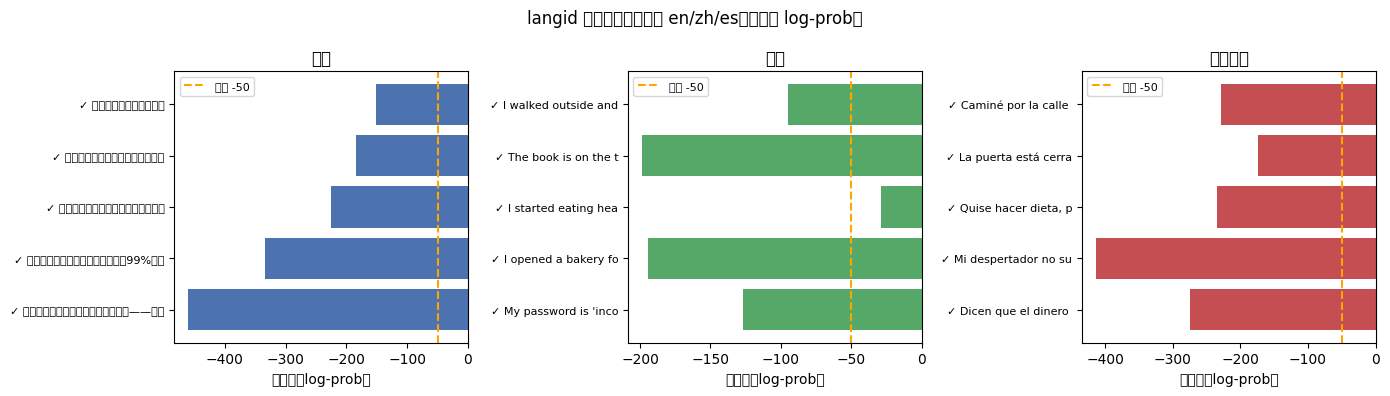

In [4]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["font.family"] = ["DejaVu Sans", "WenQuanYi Micro Hei", "Arial Unicode MS"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
lang_groups = [("中文", "zh", "#4C72B0"), ("英文", "en", "#55A868"), ("西班牙语", "es", "#C44E52")]

for ax, (lang_name, lang_code, color) in zip(axes, lang_groups):
    lang_results = [r for r in results if r["language"] == lang_name]
    confidences = [r["confidence"] for r in lang_results]
    labels = [("✓" if r["correct"] else "✗") + " " + r["text"][:20] for r in lang_results]

    bars = ax.barh(range(len(confidences)), confidences, color=[
        color if r["correct"] else "#d62728" for r in lang_results
    ])
    ax.set_yticks(range(len(confidences)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("置信度（log-prob）")
    ax.set_title(f"{lang_name}")
    ax.axvline(x=-50.0, color="orange", linestyle="--", linewidth=1.5, label="阈值 -50")
    ax.legend(fontsize=8)

plt.suptitle("langid 置信度分布（限定 en/zh/es，横向为 log-prob）", fontsize=12)
plt.tight_layout()
plt.show()
